The problem statement is that:
Water quality is a serious concern when it comes to the health of the biodiversity so it is necessary that those things are able to be kept in check and made sure that they are potable constantly.

My goal is to create a forecasting model that is able to predict the amount of **Dissolved Oxygen(DO)** in water to ensure that unsafe consumption can be prevented

In [1]:
import pandas as pd

In [2]:
df= pd.read_csv("Water_Quality_Dataset.csv")

In [3]:
df.head()

,Timestamp,Location,pH,Turbidity (NTU),Temperature (°C),DO (mg/L),BOD (mg/L),Lead (mg/L),Mercury (mg/L),Arsenic (mg/L),Pollution_Level
0,2024-01-01 00:00:00,L4,8.762414,14.468306,16.461631,6.258335,2.478582,0.002801,0.001924,0.018769,2
1,2024-01-01 01:00:00,L5,7.477966,1.905645,27.446865,2.826120,8.048453,0.019551,0.000633,0.003708,2
2,2024-01-01 02:00:00,L3,7.938278,1.889506,34.623557,3.380191,2.102481,0.019291,0.000205,0.005055,2
3,2024-01-01 03:00:00,L5,8.728748,0.736115,18.802153,6.543794,6.714160,0.003358,0.001058,0.005638,2
4,2024-01-01 04:00:00,L5,7.975335,19.151777,30.851902,4.370861,2.114614,0.006059,0.000124,0.001237,2


Here I notice that the **Timestamp** attribute is str Dtype which is not acceptable for forecasting, so that needs to be changed to Date Dtype

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Timestamp         1000 non-null   str    
 1   Location          1000 non-null   str    
 2   pH                1000 non-null   float64
 3   Turbidity (NTU)   1000 non-null   float64
 4   Temperature (°C)  1000 non-null   float64
 5   DO (mg/L)         1000 non-null   float64
 6   BOD (mg/L)        1000 non-null   float64
 7   Lead (mg/L)       1000 non-null   float64
 8   Mercury (mg/L)    1000 non-null   float64
 9   Arsenic (mg/L)    1000 non-null   float64
 10  Pollution_Level   1000 non-null   int64  
dtypes: float64(8), int64(1), str(2)
memory usage: 106.6 KB


In [5]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

In [6]:
df['Timestamp'].dtype

dtype('<M8[us]')

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
forecast_df = df[["Timestamp", "Pollution_Level"]]
forecast_df = forecast_df.sort_values("Timestamp")

In [9]:
forecast_df.head()

,Timestamp,Pollution_Level
0,2024-01-01 00:00:00,2
1,2024-01-01 01:00:00,2
2,2024-01-01 02:00:00,2
3,2024-01-01 03:00:00,2
4,2024-01-01 04:00:00,2


<Figure size 1200x500 with 0 Axes>

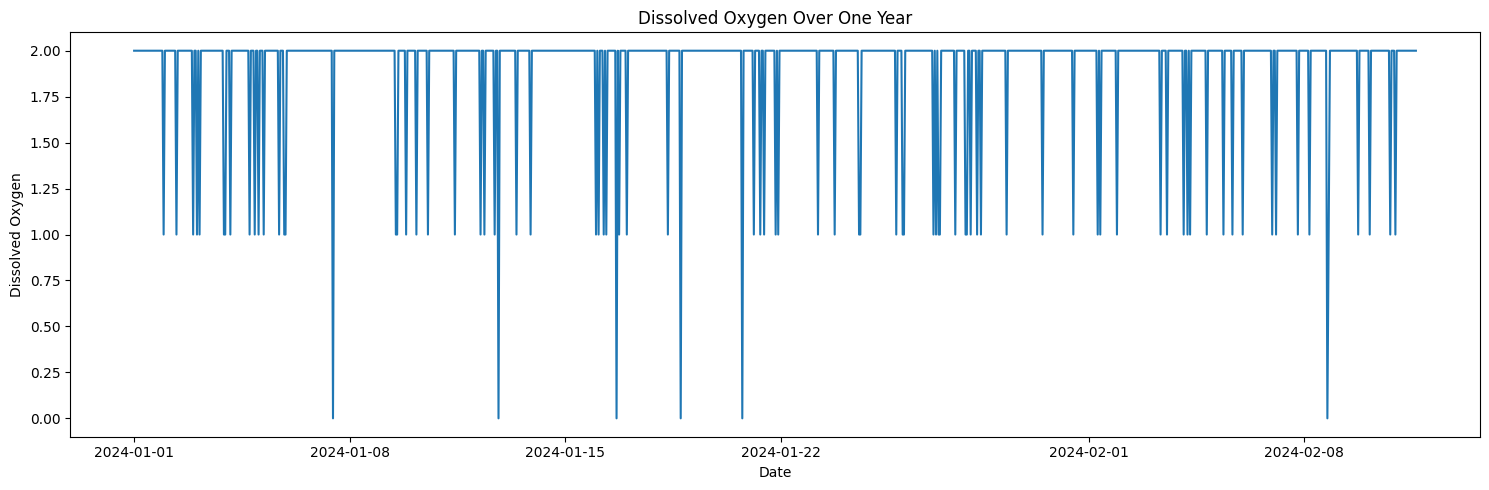

In [10]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))

plt.figure(figsize=(15, 5))

plt.plot(forecast_df['Timestamp'], forecast_df["Pollution_Level"])

plt.xlabel("Date")
plt.ylabel("Dissolved Oxygen")
plt.title("Dissolved Oxygen Over One Year")

plt.tight_layout()
plt.show()

In [11]:
print(forecast_df["Timestamp"].min())
print(forecast_df["Timestamp"].max())

2024-01-01 00:00:00
2024-02-11 15:00:00


In [12]:
print(forecast_df["Timestamp"].diff().value_counts().head(10))

Timestamp
0 days 01:00:00    999
Name: count, dtype: int64


In [13]:
forecast_df["Date"] = forecast_df["Timestamp"].dt.date

print(forecast_df["Date"].value_counts().sort_index())

Date
2024-01-01    24
2024-01-02    24
2024-01-03    24
2024-01-04    24
2024-01-05    24
2024-01-06    24
2024-01-07    24
2024-01-08    24
2024-01-09    24
2024-01-10    24
2024-01-11    24
2024-01-12    24
2024-01-13    24
2024-01-14    24
2024-01-15    24
2024-01-16    24
2024-01-17    24
2024-01-18    24
2024-01-19    24
2024-01-20    24
2024-01-21    24
2024-01-22    24
2024-01-23    24
2024-01-24    24
2024-01-25    24
2024-01-26    24
2024-01-27    24
2024-01-28    24
2024-01-29    24
2024-01-30    24
2024-01-31    24
2024-02-01    24
2024-02-02    24
2024-02-03    24
2024-02-04    24
2024-02-05    24
2024-02-06    24
2024-02-07    24
2024-02-08    24
2024-02-09    24
2024-02-10    24
2024-02-11    16
Name: count, dtype: int64


In [14]:
print(forecast_df["Timestamp"].head(30))

0    2024-01-01 00:00:00
1    2024-01-01 01:00:00
2    2024-01-01 02:00:00
3    2024-01-01 03:00:00
4    2024-01-01 04:00:00
5    2024-01-01 05:00:00
6    2024-01-01 06:00:00
7    2024-01-01 07:00:00
8    2024-01-01 08:00:00
9    2024-01-01 09:00:00
10   2024-01-01 10:00:00
11   2024-01-01 11:00:00
12   2024-01-01 12:00:00
13   2024-01-01 13:00:00
14   2024-01-01 14:00:00
15   2024-01-01 15:00:00
16   2024-01-01 16:00:00
17   2024-01-01 17:00:00
18   2024-01-01 18:00:00
19   2024-01-01 19:00:00
20   2024-01-01 20:00:00
21   2024-01-01 21:00:00
22   2024-01-01 22:00:00
23   2024-01-01 23:00:00
24   2024-01-02 00:00:00
25   2024-01-02 01:00:00
26   2024-01-02 02:00:00
27   2024-01-02 03:00:00
28   2024-01-02 04:00:00
29   2024-01-02 05:00:00
Name: Timestamp, dtype: datetime64[us]


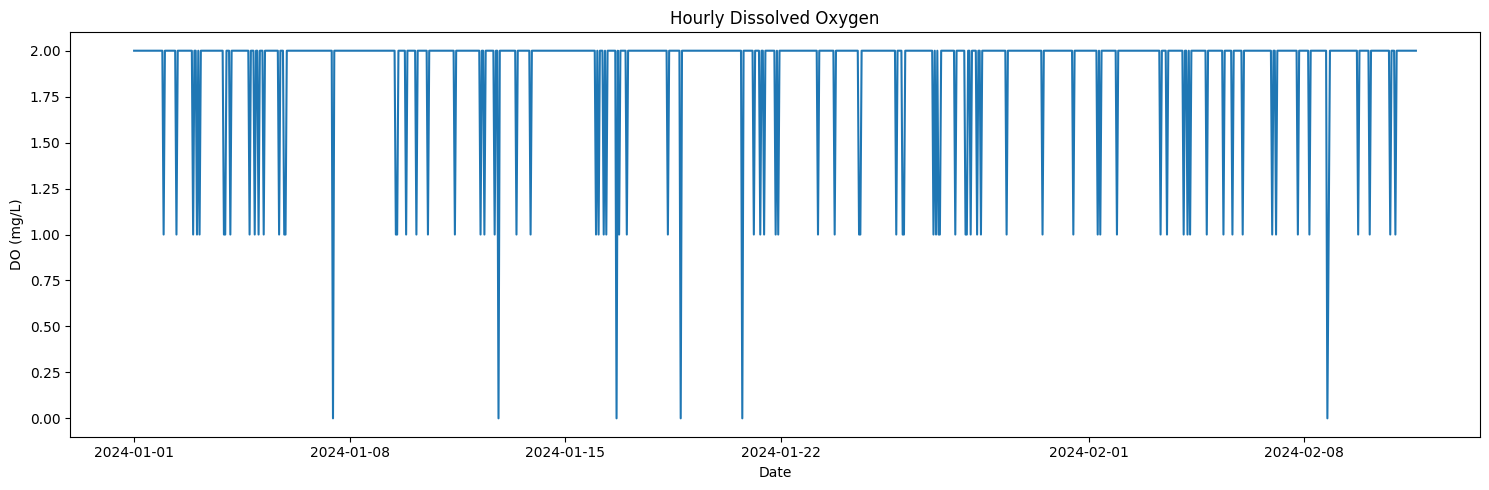

In [15]:
plt.figure(figsize=(15, 5))

plt.plot(
    forecast_df["Timestamp"],
    forecast_df["Pollution_Level"]
)

plt.xlabel("Date")
plt.ylabel("DO (mg/L)")
plt.title("Hourly Dissolved Oxygen")

plt.tight_layout()
plt.show()

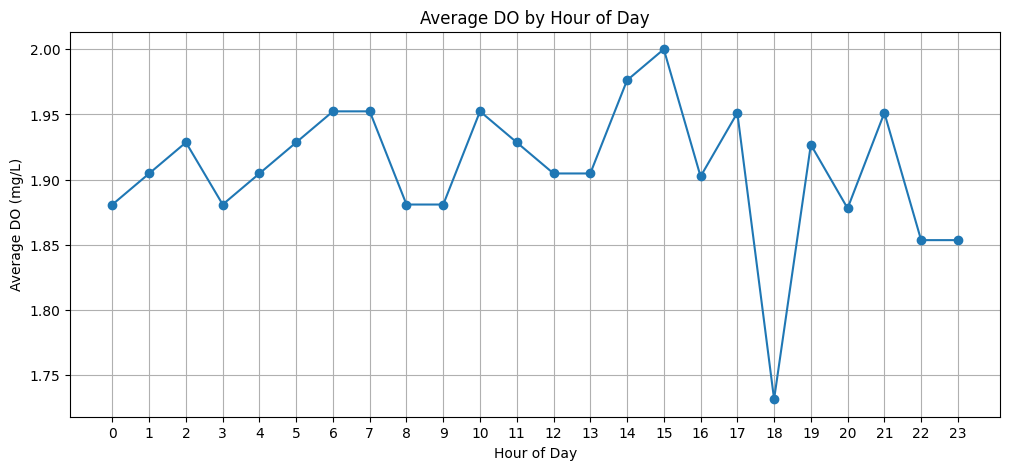

In [16]:
forecastH_df = forecast_df.copy()

forecastH_df["Hour"] = forecastH_df["Timestamp"].dt.hour

hourly_pattern = forecastH_df.groupby("Hour")["Pollution_Level"].mean()

plt.figure(figsize=(12, 5))
plt.plot(hourly_pattern.index, hourly_pattern.values, marker="o")

plt.xlabel("Hour of Day")
plt.ylabel("Average DO (mg/L)")
plt.title("Average DO by Hour of Day")

plt.xticks(range(24))
plt.grid()
plt.show()

<Figure size 1200x500 with 0 Axes>

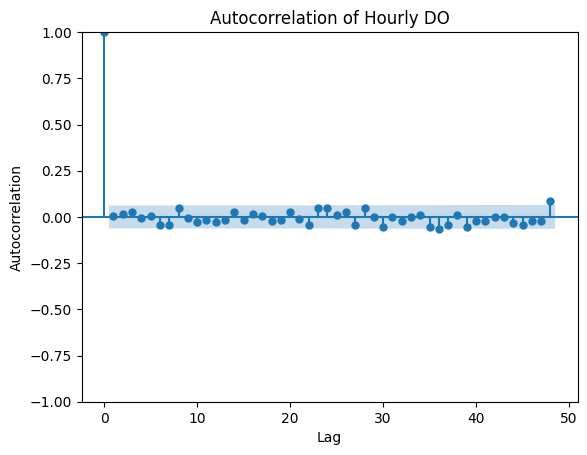

In [17]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(12, 5))

plot_acf(
    forecast_df["Pollution_Level"],
    lags=48
)

plt.title("Autocorrelation of Hourly DO")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")

plt.show()

**UNSUCCESSFUL** due to DO and Date not having any proper correlation